In [ ]:
import google
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Install Transcriptformer

In [ ]:
!pip install transcriptformer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 478.3/478.3 kB 30.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of aiobotocore to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of aiobotocore to determine which version is compat

## Torch

In [ ]:
!pip uninstall -y torch torchvision torchaudio

In [ ]:
!pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 \
--index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.2/908.2 MB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 145.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 125.7 MB/s eta 0:00:00


In [ ]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

import torchvision.ops
print("OK ✔")

2.5.1+cu124
0.20.1+cu124
OK ✔


# Imports

In [ ]:
!pip install mygene scanpy anndata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.7 MB/s eta 0:00:00


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
import warnings
import mygene
import seaborn as sns
import matplotlib.pyplot as plt
import os
import subprocess
import pandas as pd
import numpy as np
import logging
import torch
import scanpy as sc
import anndata
logging.getLogger().setLevel(logging.ERROR)

warnings.filterwarnings("ignore")

model_dir="/content/drive/MyDrive/gp/transcriptformer/transcriptformer/transcriptformer/tf_exemplar"
data_dir = "/content/drive/MyDrive/gp/datasets/data"


# Imports for classification models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import UndefinedMetricWarning
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import warnings


warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

In [ ]:
def plot_cm(y_true, y_pred, title):
    # Reset to default style to ensure consistency
    plt.rcdefaults()
    plt.rcParams.update({
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'font.family': 'sans-serif',
        'font.size': 10,
    })

    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )
    ax.grid(False)

    for text in ax.texts:
        text.set_fontsize(6)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=8)
    plt.ylabel("True label", fontsize=8)

    plt.tight_layout()
    plt.show()

# Set up evaluation function

In [ ]:
!pip install harmonypy

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from harmonypy import compute_lisi

def compute_silhouette_and_lisi_avg(adata, label_keys, embed_key, k_lisi=30):

    X = adata.obsm[embed_key]
    metadata = adata.obs[label_keys]

    # Silhouette scores
    sil_scores = {}
    for key in label_keys:
        labels = adata.obs[key].astype(str).values

        if len(np.unique(labels)) > 1:
            sil_scores[key] = silhouette_score(X, labels)
        else:
            sil_scores[key] = np.nan

    # LISI scores
    lisi_scores = compute_lisi(
        X,
        metadata,
        label_colnames=label_keys,
        perplexity=k_lisi
    )

    lisi_df = pd.DataFrame(
        lisi_scores,
        columns=label_keys,
        index=adata.obs_names
    )

    scores = {
        "silhouette": sil_scores,
        "lisi": lisi_df.mean().to_dict()
    }

    return scores

# Colon dataset Human-Monkey Integration

In [ ]:
!mkdir -p /content/drive/MyDrive/gp/transcriptformer/transcriptformer/integration/colon

## Data preprocessing

In [ ]:
colon_data_path = os.path.join(data_dir, "GP_datasets/Colon/colon_merged.h5ad")
adata = sc.read_h5ad(colon_data_path)


In [ ]:
adata

AnnData object with n_obs × n_vars = 32636 × 12502
    obs: 'cell_type', 'species', 'assay'
    uns: 'cell_type_colors', 'neighbors', 'species_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

In [ ]:
adata.obs['species'].unique()

['human', 'monkey']
Categories (2, object): ['human', 'monkey']

In [ ]:
adata.var.index

Index(['TSPAN6', 'DPM1', 'SCYL3', 'FGR', 'CFH', 'FUCA2', 'GCLC', 'NFYA',
       'STPG1', 'NIPAL3',
       ...
       'IQCJ-SCHIP1', 'SMIM33', 'EXOC3L2', 'MIR6125', 'TBCE', 'CCDC39',
       'LRTOMT', 'CDR1', 'ACTL10', 'PRRC2B'],
      dtype='object', length=12502)

In [ ]:
import scanpy as sc
import mygene

mg = mygene.MyGeneInfo()
gene_symbols = adata.var_names.tolist()

# --- 1. Get human Ensembl IDs ---
result_human = mg.querymany(gene_symbols, scopes='symbol', fields='ensembl.gene', species=9606)
human_map = {}
for r in result_human:
    if 'ensembl' in r:
        e = r['ensembl']
        human_map[r['query']] = e[0]['gene'] if isinstance(e, list) else e['gene']

# --- 2. Get macaque Ensembl IDs ---
result_monkey = mg.querymany(gene_symbols, scopes='symbol', fields='ensembl.gene', species=9544)
monkey_map = {}
for r in result_monkey:
    if 'ensembl' in r:
        e = r['ensembl']
        monkey_map[r['query']] = e[0]['gene'] if isinstance(e, list) else e['gene']

# --- 3. Split and fix ---
adata_human = adata[adata.obs['species'] == 'human'].copy()
adata_human.var['ensembl_id'] = adata_human.var_names.map(human_map)

adata_monkey = adata[adata.obs['species'] == 'monkey'].copy()
adata_monkey.var['ensembl_id'] = adata_monkey.var_names.map(monkey_map)

# --- 4. Check mapping rates ---
print(f"Human mapped: {adata_human.var['ensembl_id'].notna().sum()} / {len(adata_human.var)}")
print(f"Monkey mapped: {adata_monkey.var['ensembl_id'].notna().sum()} / {len(adata_monkey.var)}")

# --- 5. Save ---
human_data = '/content/drive/MyDrive/gp/datasets/data/colon/colon_human.h5ad'
monkey_data = '/content/drive/MyDrive/gp/datasets/data/colon/colon_monkey.h5ad'

adata_human.write_h5ad(human_data)
adata_monkey.write_h5ad(monkey_data)

print("Saved!")

INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-12502 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.
INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:b

Human mapped: 12435 / 12502
Monkey mapped: 11797 / 12502
Saved!


In [ ]:
adata

AnnData object with n_obs × n_vars = 32636 × 12502
    obs: 'cell_type', 'species', 'assay'
    var: 'ensembl_id'
    uns: 'cell_type_colors', 'neighbors', 'species_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

In [ ]:
adata.obs['assay'].unique()

['Smart-seq2', '10x 3' v3', '10x Chromium']
Categories (3, object): ['10x 3' v3', '10x Chromium', 'Smart-seq2']

In [ ]:
adata.write(os.path.join(data_dir, "colon/colon.h5ad"))

## Get embeddings

In [ ]:
# data=os.path.join(data_dir, "colon/colon.h5ad")
embeddings_dir="/content/drive/MyDrive/gp/transcriptformer/integration/pancreas"

In [ ]:
!transcriptformer inference --help

usage: transcriptformer inference [-h] --checkpoint-path CHECKPOINT_PATH
                                  --data-file DATA_FILE
                                  [--output-path OUTPUT_PATH]
                                  [--output-filename OUTPUT_FILENAME]
                                  [--batch-size BATCH_SIZE]
                                  [--gene-col-name GENE_COL_NAME]
                                  [--precision {16-mixed,32}]
                                  [--pretrained-embedding PRETRAINED_EMBEDDING]
                                  [--clip-counts CLIP_COUNTS]
                                  [--filter-to-vocabs]
                                  [--model-type {transcriptformer,esm2ce}]
                                  [--use-raw USE_RAW] [--emb-type {cell,cge}]
                                  [--remove-duplicate-genes]
                                  [--num-gpus NUM_GPUS]
                                  [--device {auto,cpu,cuda,mps}]
                   

In [ ]:
human_data = '/content/drive/MyDrive/gp/datasets/data/colon/colon_human.h5ad'
monkey_data = '/content/drive/MyDrive/gp/datasets/data/colon/colon_monkey.h5ad'
monkey_embed='/content/drive/MyDrive/gp/transcriptformer/transcriptformer/transcriptformer/all_embeddings/macaca_mulatta_gene.h5'

In [ ]:
# Human
!transcriptformer inference \
    --checkpoint-path {model_dir} \
    --data-file {human_data} \
    --output-path {embeddings_dir} \
    --batch-size 8 \
    --remove-duplicate-genes \
    --gene-col-name ensembl_id \
    --output-filename transcriptformer_colon_human_embeddings.h5ad

# Monkey (uses the pretrained monkey embedding)
!transcriptformer inference \
    --checkpoint-path {model_dir} \
    --data-file {monkey_data} \
    --output-path {embeddings_dir} \
    --batch-size 8 \
    --remove-duplicate-genes \
    --gene-col-name ensembl_id \
    --pretrained-embedding {monkey_embed} \
    --output-filename transcriptformer_colon_monkey_embeddings.h5ad


 ___________  ___   _   _  _____           _       _  ______ ______________  ___ ___________
|_   _| ___ \/ _ \ | \ | |/  ___|         (_)     | | |  ___|  _  | ___ \  \/  ||  ___| ___ \
  | | | |_/ / /_\ \|  \| |\ `--.  ___ _ __ _ _ __ | |_| |_  | | | | |_/ / .  . || |__ | |_/ /
  | | |    /|  _  || . ` | `--. \/ __| '__| | '_ \| __|  _| | | | |    /| |\/| ||  __||    /
  | | | |\ \| | | || |\  |/\__/ / (__| |  | | |_) | |_| |   \ \_/ / |\ \| |  | || |___| |\ \
  \_/ \_| \_\_| |_/\_| \_/\____/ \___|_|  |_| .__/ \__\_|    \___/\_| \_\_|  |_/\____/\_| \_|
                                            | |
                                            |_|

2026-04-26 13:36:40,387 - INFO - Loading vocabulary file: /content/drive/MyDrive/gp/transcriptformer/transcriptformer/transcriptformer/tf_exemplar/vocabs/assay
2026-04-26 13:36:40,389 - INFO - Loading ESM2 mappings from /content/drive/MyDrive/gp/transcriptformer/transcriptformer/transcriptformer/tf_exemplar/vocabs
2026-04-26 13:36:59,897 -

In [ ]:
import scanpy as sc

In [ ]:
human_emb = sc.read_h5ad(f'{embeddings_dir}/transcriptformer_colon_human_embeddings.h5ad')
monkey_emb = sc.read_h5ad(f'{embeddings_dir}/transcriptformer_colon_monkey_embeddings.h5ad')

adata = sc.concat([human_emb, monkey_emb], join='inner')

# adata.write_h5ad(f'{embeddings_dir}/transcriptformer_colon2_cross_species_embeddings.h5ad')
# print(adata)

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1878: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
adata

AnnData object with n_obs × n_vars = 32636 × 0
    obs: 'cell_type', 'species', 'assay'
    obsm: 'embeddings'

In [ ]:
adata = sc.read_h5ad(os.path.join(embeddings_dir,"transcriptformer_colon2_cross_species_embeddings.h5ad"))


In [ ]:
adata

AnnData object with n_obs × n_vars = 32636 × 0
    obs: 'cell_type', 'species', 'assay'
    obsm: 'embeddings'

In [ ]:
adata.obsm['embeddings']

array([[-3.5800353e-02,  2.7542129e-02,  6.7166433e-02, ...,
        -2.4924497e-01,  1.8050563e-01,  8.4002845e-02],
       [-2.2218331e-04,  1.0056308e-01,  8.9274287e-02, ...,
        -3.8234252e-01,  1.9455500e-01,  6.0534373e-02],
       [-3.5026971e-02,  5.0603028e-02,  6.4079635e-02, ...,
        -1.5139954e-01,  1.1952768e-01,  6.9560580e-02],
       ...,
       [-5.7987314e-02,  4.2404136e-01,  7.3290151e-01, ...,
         9.0959662e-01,  2.6417622e-01,  6.0164636e-01],
       [ 1.6135259e-01,  4.2979085e-01,  3.4044874e-01, ...,
         5.7870907e-01,  2.7814364e-01,  5.0128877e-01],
       [ 8.9712396e-02,  5.8107984e-01,  5.8423197e-01, ...,
         7.5075638e-01,  2.7194169e-01,  3.9079228e-01]], dtype=float32)

In [ ]:
adata.obsm['X_transcriptformer'] = adata.obsm.pop('embeddings')


In [ ]:
sc.pp.neighbors(adata, use_rep="X_transcriptformer")
sc.tl.umap(adata)

In [ ]:
adata

AnnData object with n_obs × n_vars = 32636 × 0
    obs: 'cell_type', 'species', 'assay'
    uns: 'neighbors', 'umap'
    obsm: 'X_transcriptformer', 'X_umap'
    obsp: 'distances', 'connectivities'

In [ ]:
adata.write(os.path.join(embeddings_dir,"transcriptformer_colon2_cross_species_embeddings.h5ad"))

## Visualization

In [ ]:
adata=sc.read_h5ad(os.path.join(embeddings_dir,"transcriptformer_colon2_cross_species_embeddings.h5ad"))

In [ ]:
adata

AnnData object with n_obs × n_vars = 32636 × 0
    obs: 'cell_type', 'species', 'assay'
    uns: 'neighbors', 'umap'
    obsm: 'X_transcriptformer', 'X_umap'
    obsp: 'connectivities', 'distances'

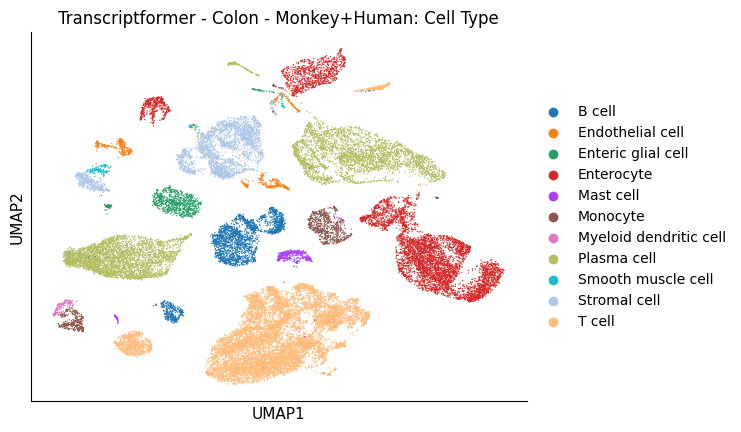

In [ ]:
ax = sc.pl.umap(
    adata,
    color='cell_type',
    frameon=True,
    title=[
        "Transcriptformer - Colon - Monkey+Human: Cell Type"],
    show=False,
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

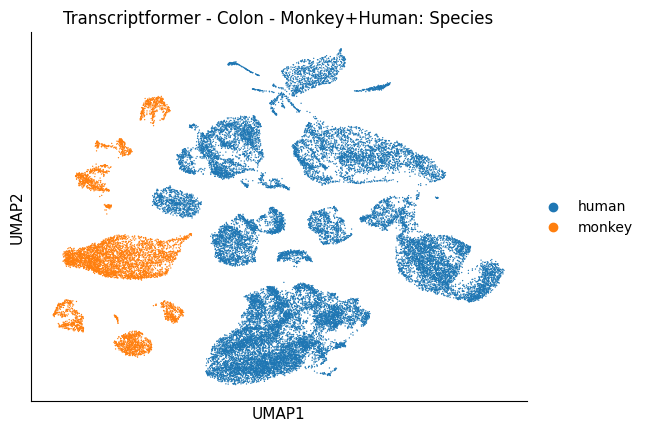

In [ ]:
ax = sc.pl.umap(
    adata,
    color='species',
    frameon=True,
    title=[
        "Transcriptformer - Colon - Monkey+Human: Species"],
    show=False,
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

## Evaluate the integration performance

In [ ]:
adata

AnnData object with n_obs × n_vars = 32636 × 0
    obs: 'cell_type', 'species', 'assay'
    uns: 'neighbors', 'umap'
    obsm: 'X_transcriptformer', 'X_umap'
    obsp: 'connectivities', 'distances'

In [ ]:
label_keys = ["cell_type", "species"]
scores = compute_silhouette_and_lisi_avg(adata, label_keys,embed_key="X_transcriptformer")

print("Silhouette scores:", scores["silhouette"])
print("LISI scores:", scores["lisi"])

Silhouette scores: {'cell_type': np.float32(0.15118873), 'species': np.float32(0.12624533)}
LISI scores: {'cell_type': 1.023209627338404, 'species': 1.000310283011687}


## Label Transfer Human=>Monkey

In [ ]:
adata

AnnData object with n_obs × n_vars = 32636 × 0
    obs: 'cell_type', 'species', 'assay'
    uns: 'neighbors', 'umap'
    obsm: 'X_transcriptformer', 'X_umap'
    obsp: 'connectivities', 'distances'

In [ ]:
adata.obs['species'].value_counts()

,count
species,
human,26069
monkey,6567


In [ ]:
train_data = adata[adata.obs['species'] == 'human'].copy()
test_data  = adata[adata.obs['species'] == 'monkey'].copy()

X_train = train_data.obsm["X_transcriptformer"]
X_test  = test_data.obsm["X_transcriptformer"]

y_train = train_data.obs["cell_type"]
y_test  = test_data.obs["cell_type"]


In [ ]:
adata

AnnData object with n_obs × n_vars = 32636 × 0
    obs: 'cell_type', 'species', 'assay'
    uns: 'neighbors', 'umap'
    obsm: 'X_transcriptformer', 'X_umap'
    obsp: 'connectivities', 'distances'

In [ ]:
# logistic regression
clf = LogisticRegression(max_iter=300, multi_class='multinomial', solver='lbfgs')

clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)

# KNN
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

=== Logistic Regression ===
Accuracy: 0.901477082381605
                        precision    recall  f1-score   support

                B cell       0.99      0.92      0.95       326
      Endothelial cell       1.00      0.73      0.85       275
    Enteric glial cell       0.94      0.93      0.94        70
            Enterocyte       1.00      0.99      0.99       405
             Mast cell       1.00      0.88      0.93        49
              Monocyte       0.69      0.05      0.10       334
Myeloid dendritic cell       0.18      0.46      0.26       137
           Plasma cell       0.99      1.00      0.99      3698
    Smooth muscle cell       0.01      0.01      0.01       126
          Stromal cell       0.76      0.99      0.86       407
                T cell       0.87      1.00      0.93       740

              accuracy                           0.90      6567
             macro avg       0.77      0.72      0.71      6567
          weighted avg       0.91      0.90   

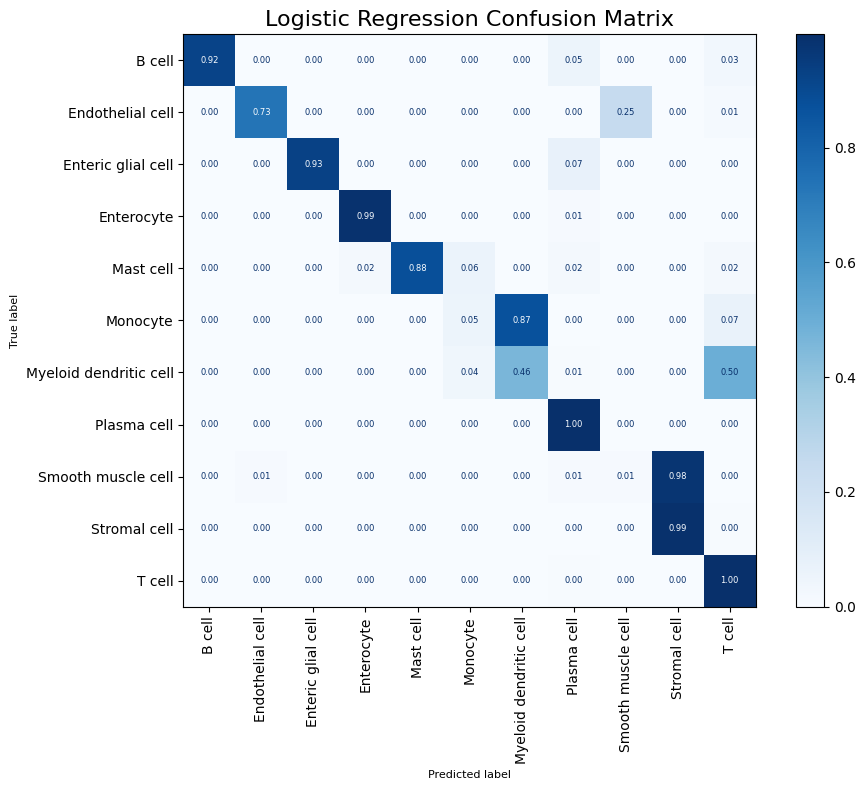


=== k-NN ===
Accuracy: 0.9436576823511497
                        precision    recall  f1-score   support

                B cell       0.86      0.87      0.87       326
      Endothelial cell       1.00      0.75      0.86       275
    Enteric glial cell       0.94      0.94      0.94        70
            Enterocyte       1.00      0.99      1.00       405
             Mast cell       0.98      1.00      0.99        49
              Monocyte       0.98      0.79      0.88       334
Myeloid dendritic cell       0.66      0.72      0.69       137
           Plasma cell       0.98      1.00      0.99      3698
    Smooth muscle cell       0.00      0.00      0.00       126
          Stromal cell       0.76      0.99      0.86       407
                T cell       1.00      0.99      0.99       740

              accuracy                           0.94      6567
             macro avg       0.83      0.82      0.82      6567
          weighted avg       0.94      0.94      0.94      

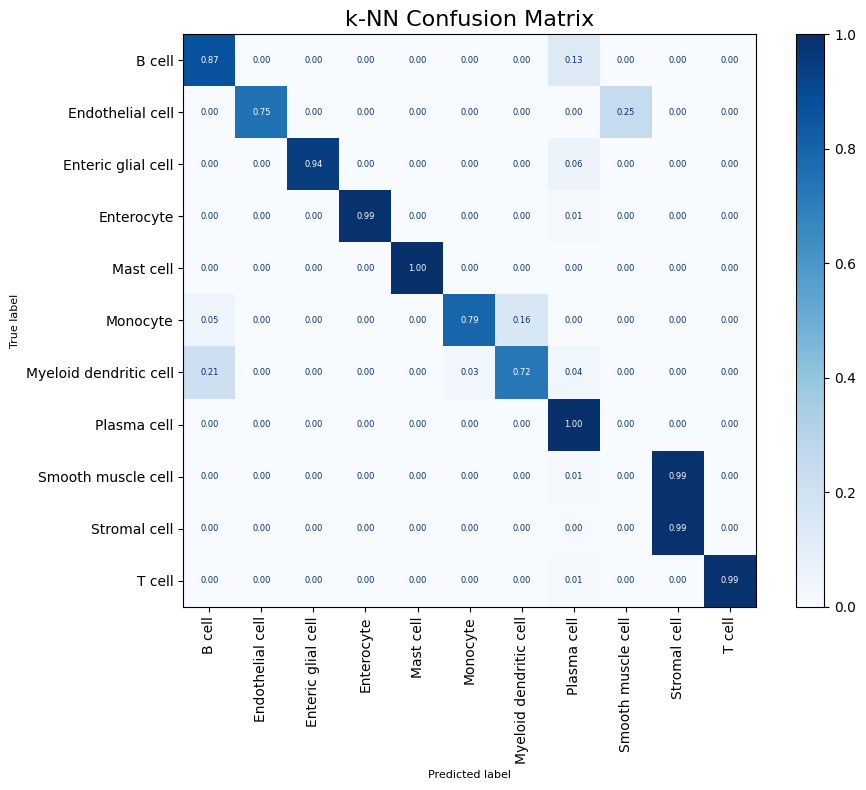

In [ ]:
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
plot_cm(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
plot_cm(y_test, y_pred_knn, "k-NN Confusion Matrix")

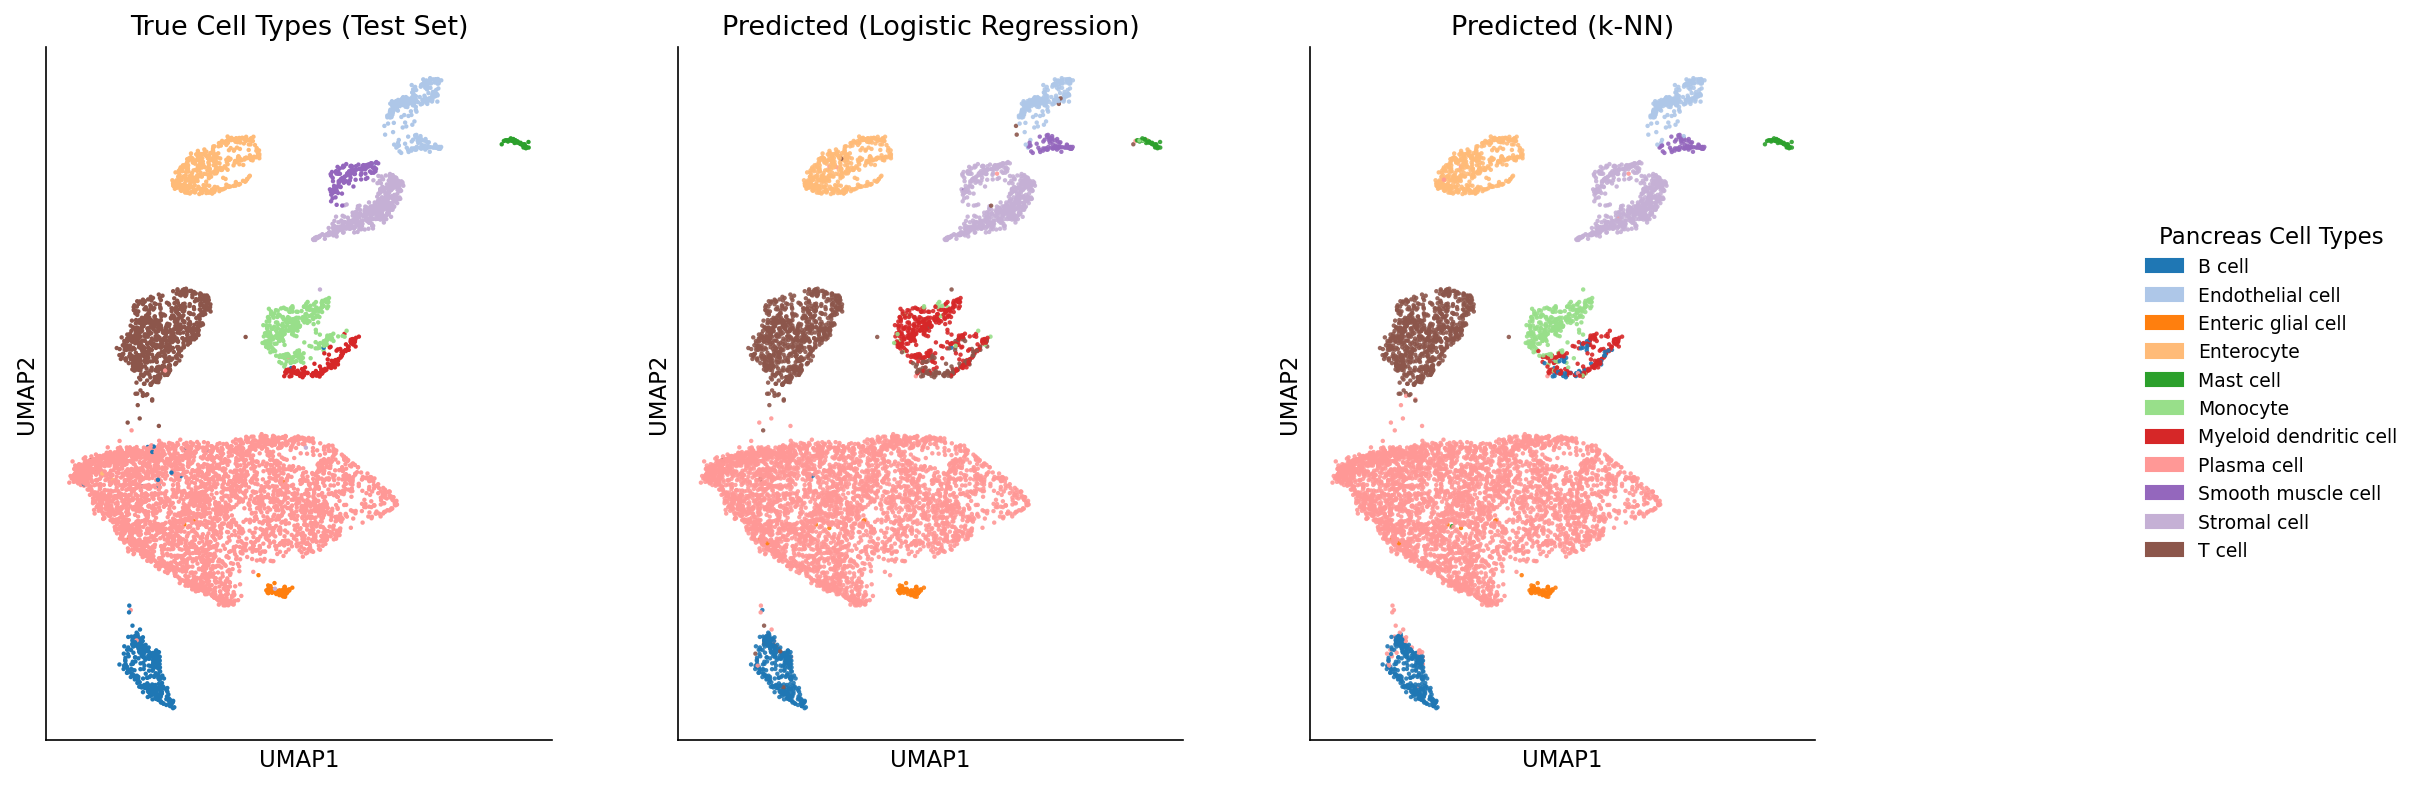

In [ ]:
# Attach predictions to test dataset
test_data.obs["y_pred_lr"] = y_pred_lr
test_data.obs["y_pred_knn"] = y_pred_knn

# Fill missing values
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype(str).fillna("Unassigned")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype(str).fillna("Unassigned")

# Convert to categorical
test_data.obs["cell_type"] = test_data.obs["cell_type"].astype("category")
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype("category")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype("category")

# Unified label set
all_labels = sorted(
    set(test_data.obs["cell_type"].cat.categories)
    | set(test_data.obs["y_pred_lr"].cat.categories)
    | set(test_data.obs["y_pred_knn"].cat.categories)
)

# Force same category order
test_data.obs["cell_type"] = test_data.obs["cell_type"].cat.set_categories(all_labels)
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].cat.set_categories(all_labels)
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].cat.set_categories(all_labels)

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels)}
color_map["Unassigned"] = "lightgray"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=150)

common_kwargs = dict(
    show=False,
    size=18,
    frameon=True,
    palette=color_map
)

# True labels
sc.pl.umap(test_data, color="cell_type", ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Test Set)", fontsize=13)

# Logistic Regression predictions
sc.pl.umap(test_data, color="y_pred_lr", ax=axes[1], alpha=0.9, **common_kwargs)
axes[1].set_title("Predicted (Logistic Regression)", fontsize=13)

# KNN predictions
sc.pl.umap(test_data, color="y_pred_knn", ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (k-NN)", fontsize=13)

# Remove auto legends
for ax in axes:
    # Remove auto legend
    if ax.legend_:
        ax.legend_.remove()

    # Force white background
    ax.set_facecolor("white")

    # Axis labels
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)

    # Make axis lines visible
    ax.spines[['left', 'bottom']].set_visible(True)

    # Remove top/right box lines (clean style)
    ax.spines[['top', 'right']].set_visible(False)

    # Make axes black
    ax.spines[['left', 'bottom']].set_color("black")

    # Ticks
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        colors='black'
    )
# Single clean legend
handles = [Patch(color=color_map[label], label=label) for label in all_labels]
fig.legend(
    handles=handles,
    title="Pancreas Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)
plt.subplots_adjust(right=0.78, wspace=0.25)
plt.show()

## Label Transfer Monkey=>Human

In [ ]:
adata

AnnData object with n_obs × n_vars = 32636 × 0
    obs: 'cell_type', 'species', 'assay'
    uns: 'neighbors', 'umap'
    obsm: 'X_transcriptformer', 'X_umap'
    obsp: 'connectivities', 'distances'

In [ ]:
adata.obs['species'].value_counts()

,count
species,
human,26069
monkey,6567


In [ ]:
train_data = adata[adata.obs['species'] == 'monkey'].copy()
test_data  = adata[adata.obs['species'] == 'human'].copy()

X_train = train_data.obsm["X_transcriptformer"]
X_test  = test_data.obsm["X_transcriptformer"]


y_train = train_data.obs["cell_type"]
y_test  = test_data.obs["cell_type"]


In [ ]:
# logistic regression
clf = LogisticRegression(max_iter=300, multi_class='multinomial', solver='lbfgs')

clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)

# KNN
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

=== Logistic Regression ===
Accuracy: 0.9448770570409298
                        precision    recall  f1-score   support

                B cell       0.98      0.98      0.98      2069
      Endothelial cell       0.78      0.82      0.80       348
    Enteric glial cell       0.99      0.99      0.99       848
            Enterocyte       0.99      0.91      0.95      5657
             Mast cell       0.99      0.94      0.97       393
              Monocyte       0.95      0.98      0.96       748
Myeloid dendritic cell       0.25      0.03      0.05        40
           Plasma cell       0.84      0.98      0.90      3308
    Smooth muscle cell       0.00      0.01      0.00        82
          Stromal cell       0.99      0.79      0.88      2597
                T cell       0.99      1.00      0.99      9979

              accuracy                           0.94     26069
             macro avg       0.80      0.77      0.77     26069
          weighted avg       0.96      0.94  

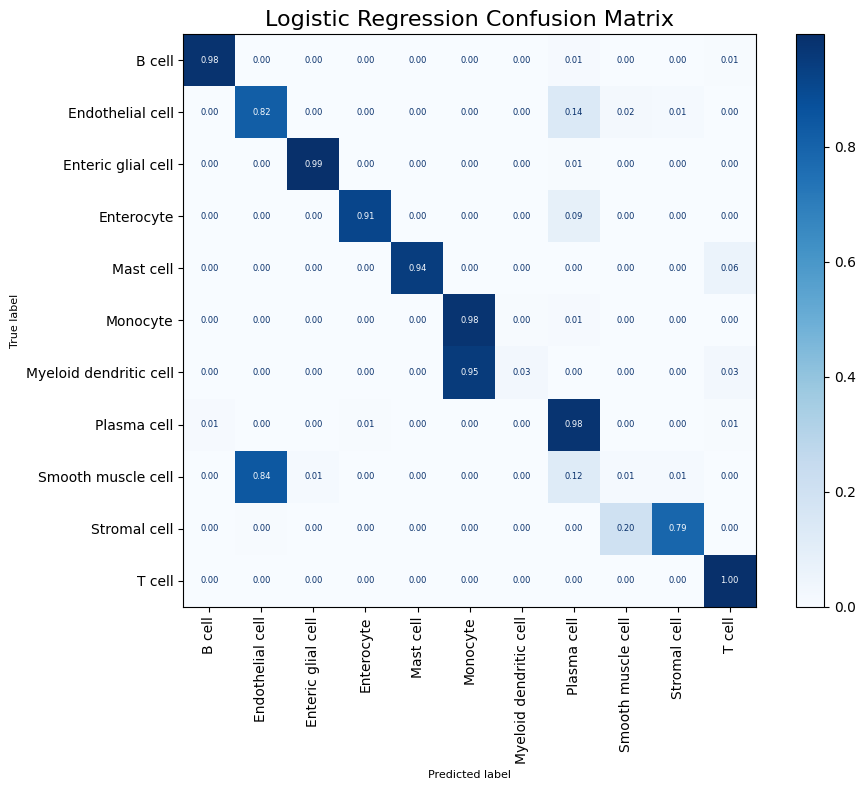


=== k-NN ===
Accuracy: 0.9165292109401971
                        precision    recall  f1-score   support

                B cell       1.00      0.92      0.96      2069
      Endothelial cell       0.78      0.69      0.73       348
    Enteric glial cell       0.99      0.99      0.99       848
            Enterocyte       1.00      0.84      0.91      5657
             Mast cell       1.00      0.87      0.93       393
              Monocyte       0.95      0.93      0.94       748
Myeloid dendritic cell       0.33      0.05      0.09        40
           Plasma cell       0.68      0.99      0.81      3308
    Smooth muscle cell       0.00      0.01      0.00        82
          Stromal cell       1.00      0.80      0.89      2597
                T cell       0.99      0.98      0.98      9979

              accuracy                           0.92     26069
             macro avg       0.79      0.73      0.75     26069
          weighted avg       0.95      0.92      0.92     2

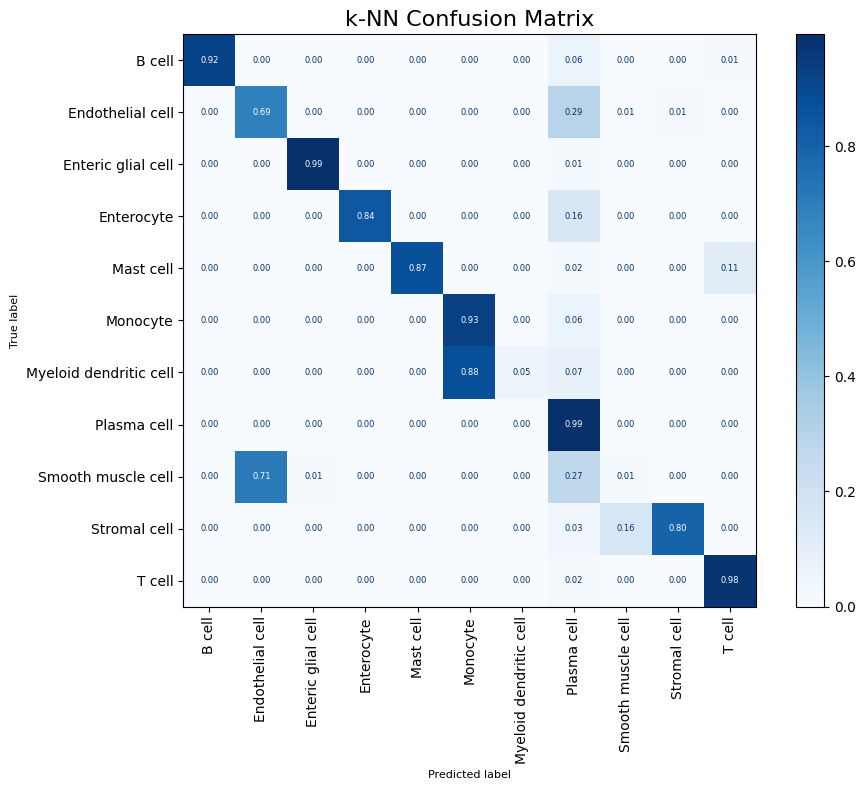

In [ ]:
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
plot_cm(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
plot_cm(y_test, y_pred_knn, "k-NN Confusion Matrix")

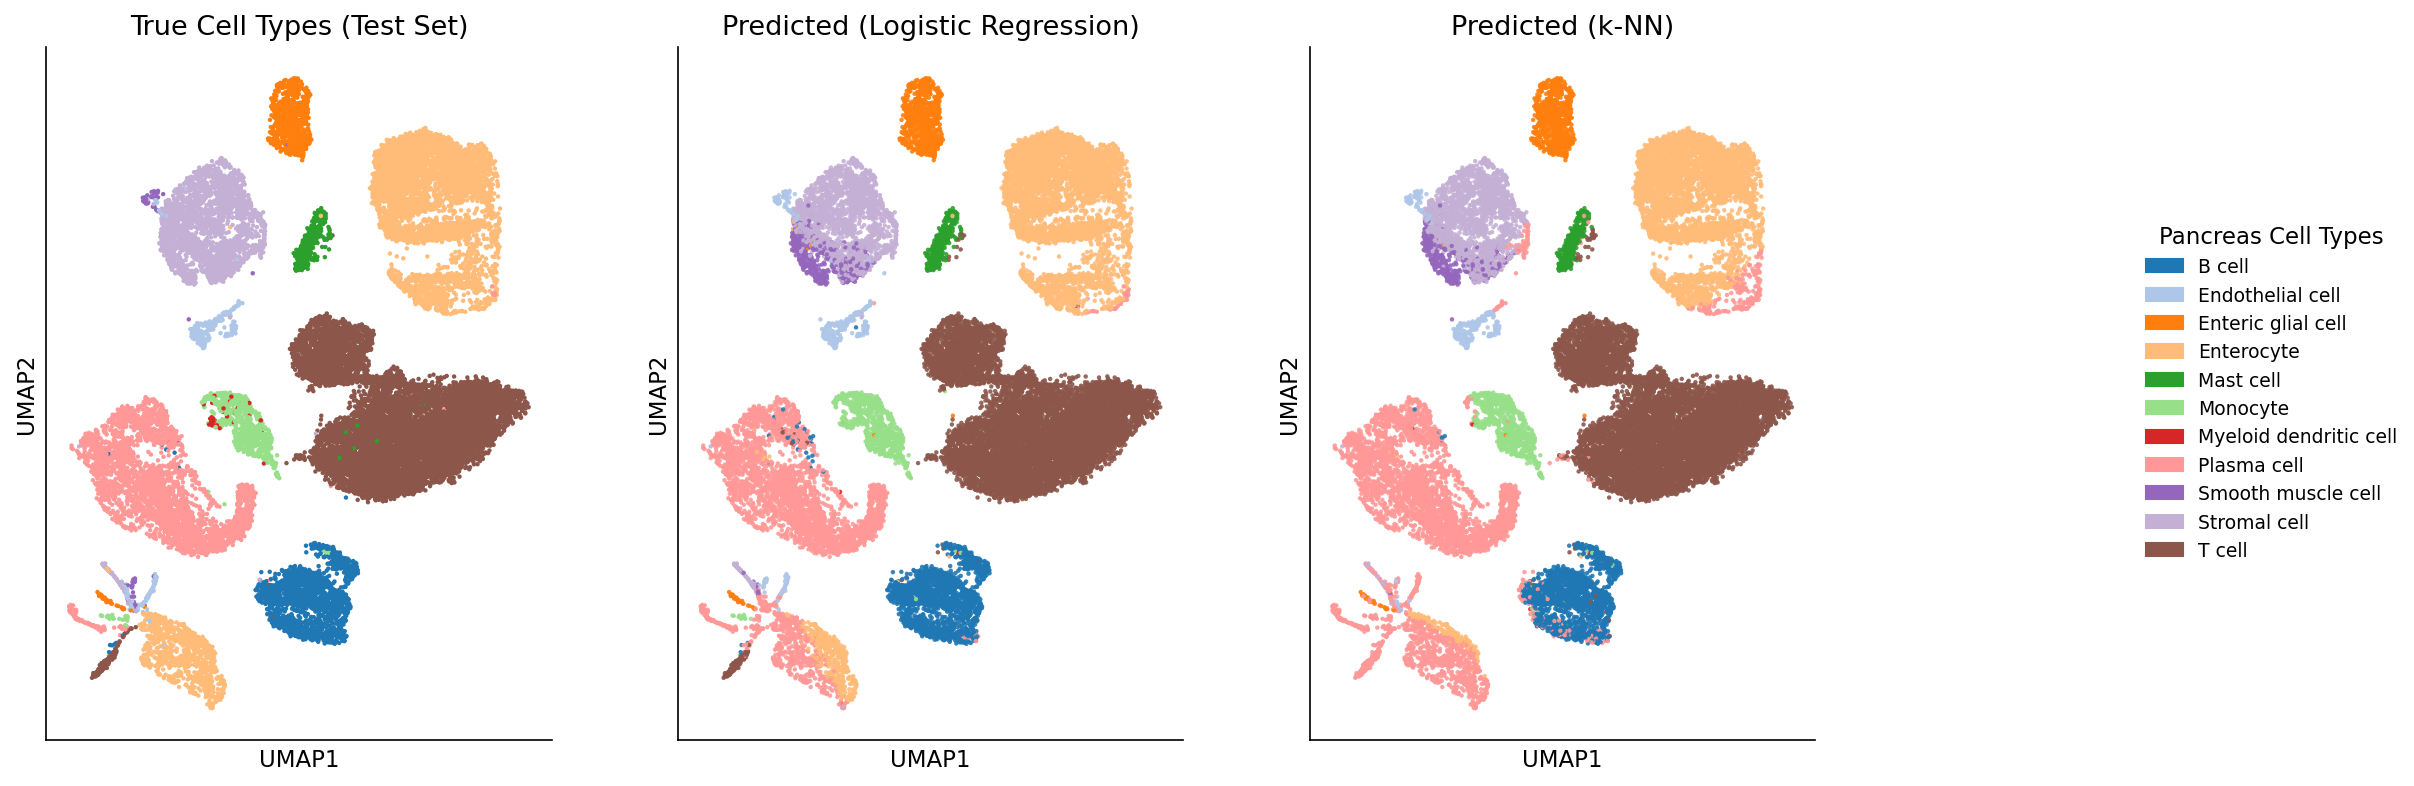

In [ ]:
# Attach predictions to test dataset
test_data.obs["y_pred_lr"] = y_pred_lr
test_data.obs["y_pred_knn"] = y_pred_knn

# Fill missing values
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype(str).fillna("Unassigned")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype(str).fillna("Unassigned")

# Convert to categorical
test_data.obs["cell_type"] = test_data.obs["cell_type"].astype("category")
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype("category")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype("category")

# Unified label set
all_labels = sorted(
    set(test_data.obs["cell_type"].cat.categories)
    | set(test_data.obs["y_pred_lr"].cat.categories)
    | set(test_data.obs["y_pred_knn"].cat.categories)
)

# Force same category order
test_data.obs["cell_type"] = test_data.obs["cell_type"].cat.set_categories(all_labels)
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].cat.set_categories(all_labels)
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].cat.set_categories(all_labels)

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels)}
color_map["Unassigned"] = "lightgray"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=150)

common_kwargs = dict(
    show=False,
    size=18,
    frameon=True,
    palette=color_map
)

# True labels
sc.pl.umap(test_data, color="cell_type", ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Test Set)", fontsize=13)

# Logistic Regression predictions
sc.pl.umap(test_data, color="y_pred_lr", ax=axes[1], alpha=0.9, **common_kwargs)
axes[1].set_title("Predicted (Logistic Regression)", fontsize=13)

# KNN predictions
sc.pl.umap(test_data, color="y_pred_knn", ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (k-NN)", fontsize=13)

# Remove auto legends
for ax in axes:
    # Remove auto legend
    if ax.legend_:
        ax.legend_.remove()

    # Force white background
    ax.set_facecolor("white")

    # Axis labels
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)

    # Make axis lines visible
    ax.spines[['left', 'bottom']].set_visible(True)

    # Remove top/right box lines (clean style)
    ax.spines[['top', 'right']].set_visible(False)

    # Make axes black
    ax.spines[['left', 'bottom']].set_color("black")

    # Ticks
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        colors='black'
    )
# Single clean legend
handles = [Patch(color=color_map[label], label=label) for label in all_labels]
fig.legend(
    handles=handles,
    title="Pancreas Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)
plt.subplots_adjust(right=0.78, wspace=0.25)
plt.show()

# Pnacreas dataset Human-Mouse Integration

In [ ]:
!mkdir -p /content/drive/MyDrive/gp/transcriptformer/transcriptformer/integration/pancreas

## Data preprocessing

In [ ]:
mouse_data_path = os.path.join(data_dir, "GP_datasets/Pancreas/Baron_Pancreas_Combined_Human_Mouse.h5ad")
adata = sc.read_h5ad(mouse_data_path)


In [ ]:
adata

AnnData object with n_obs × n_vars = 9436 × 10335
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch'

In [ ]:
adata.obs['species'].unique()

['mouse', 'human']
Categories (2, object): ['human', 'mouse']

In [ ]:
adata.var.index

Index(['A1CF', 'A4GALT', 'AAAS', 'AACS', 'AADAC', 'AAED1', 'AAGAB', 'AAK1',
       'AAMDC', 'AAMP',
       ...
       'SPRYD3', 'SPRYD4', 'SPRYD7', 'SPSB1', 'SPSB2', 'SPSB3', 'SPSB4',
       'SPTAN1', 'SPTB', 'SPTBN1'],
      dtype='object', length=10335)

In [ ]:
adata.obs['assay'] = 'inDrop'


In [ ]:
adata

AnnData object with n_obs × n_vars = 9436 × 10335
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch', 'assay'
    var: 'ensembl_id'

In [ ]:
adata.write(os.path.join(data_dir, "pancreas/pancreas_species.h5ad"))

In [ ]:
data=os.path.join(data_dir, "pancreas/pancreas_species.h5ad")
embeddings_dir="/content/drive/MyDrive/gp/transcriptformer/transcriptformer/integration/pancreas"

In [ ]:
!transcriptformer inference --help

usage: transcriptformer inference [-h] --checkpoint-path CHECKPOINT_PATH
                                  --data-file DATA_FILE
                                  [--output-path OUTPUT_PATH]
                                  [--output-filename OUTPUT_FILENAME]
                                  [--batch-size BATCH_SIZE]
                                  [--gene-col-name GENE_COL_NAME]
                                  [--precision {16-mixed,32}]
                                  [--pretrained-embedding PRETRAINED_EMBEDDING]
                                  [--clip-counts CLIP_COUNTS]
                                  [--filter-to-vocabs]
                                  [--model-type {transcriptformer,esm2ce}]
                                  [--use-raw USE_RAW] [--emb-type {cell,cge}]
                                  [--remove-duplicate-genes]
                                  [--num-gpus NUM_GPUS]
                                  [--device {auto,cpu,cuda,mps}]
                   

## Get embeddings

In [ ]:
!transcriptformer inference \
    --checkpoint-path {model_dir} \
    --data-file {data} \
    --output-path {embeddings_dir} \
    --batch-size 8 \
    --remove-duplicate-genes \
    --output-filename transcriptformer_pancreas_cross_species_embeddings.h5ad


 ___________  ___   _   _  _____           _       _  ______ ______________  ___ ___________
|_   _| ___ \/ _ \ | \ | |/  ___|         (_)     | | |  ___|  _  | ___ \  \/  ||  ___| ___ \
  | | | |_/ / /_\ \|  \| |\ `--.  ___ _ __ _ _ __ | |_| |_  | | | | |_/ / .  . || |__ | |_/ /
  | | |    /|  _  || . ` | `--. \/ __| '__| | '_ \| __|  _| | | | |    /| |\/| ||  __||    /
  | | | |\ \| | | || |\  |/\__/ / (__| |  | | |_) | |_| |   \ \_/ / |\ \| |  | || |___| |\ \
  \_/ \_| \_\_| |_/\_| \_/\____/ \___|_|  |_| .__/ \__\_|    \___/\_| \_\_|  |_/\____/\_| \_|
                                            | |
                                            |_|

2026-04-24 16:52:42,818 - INFO - Loading vocabulary file: /content/drive/MyDrive/gp/transcriptformer/transcriptformer/transcriptformer/tf_exemplar/vocabs/assay
2026-04-24 16:52:44,091 - INFO - Loading ESM2 mappings from /content/drive/MyDrive/gp/transcriptformer/transcriptformer/transcriptformer/tf_exemplar/vocabs
2026-04-24 16:53:39,160 -

In [ ]:
adata

AnnData object with n_obs × n_vars = 9436 × 10335
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch', 'assay'
    var: 'ensembl_id'

In [ ]:
adata = sc.read_h5ad(os.path.join(embeddings_dir,"transcriptformer_pancreas_cross_species_embeddings.h5ad"))


In [ ]:
adata

AnnData object with n_obs × n_vars = 9436 × 0
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch', 'assay'
    obsm: 'embeddings'

In [ ]:
adata.obsm['embeddings']

array([[ 0.21370037,  0.31763124,  0.3625925 , ...,  0.44892827,
         0.42880234,  0.44999966],
       [ 0.29764798,  0.30075616,  0.2886502 , ...,  0.36884785,
         0.23173828,  0.36517766],
       [ 0.30269638,  0.267829  ,  0.26134706, ...,  0.15749873,
         0.16457205,  0.2954722 ],
       ...,
       [ 0.05877833,  0.1268725 ,  0.15452376, ...,  0.12638082,
         0.04773308,  0.19810036],
       [ 0.16538502,  0.12923385,  0.16961682, ...,  0.07333198,
         0.04875885,  0.17533189],
       [ 0.01574062,  0.04779691,  0.12774347, ..., -0.00718737,
         0.0577371 ,  0.12769756]], shape=(7568, 2048), dtype=float32)

In [ ]:
adata.obsm['X_transcriptformer'] = adata.obsm.pop('embeddings')


In [ ]:
sc.pp.neighbors(adata, use_rep="X_transcriptformer")
sc.tl.umap(adata)

In [ ]:
adata

AnnData object with n_obs × n_vars = 9436 × 0
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch', 'assay'
    uns: 'neighbors', 'umap'
    obsm: 'X_transcriptformer', 'X_umap'
    obsp: 'distances', 'connectivities'

In [ ]:
adata.write(os.path.join(embeddings_dir,"transcriptformer_pancreas_cross_species_embeddings.h5ad"))

## Visualization

In [ ]:
adata=sc.read_h5ad(os.path.join(embeddings_dir,"transcriptformer_pancreas_cross_species_embeddings.h5ad"))

In [ ]:
adata

AnnData object with n_obs × n_vars = 9436 × 0
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch', 'assay'
    uns: 'neighbors', 'umap'
    obsm: 'X_transcriptformer', 'X_umap'
    obsp: 'connectivities', 'distances'

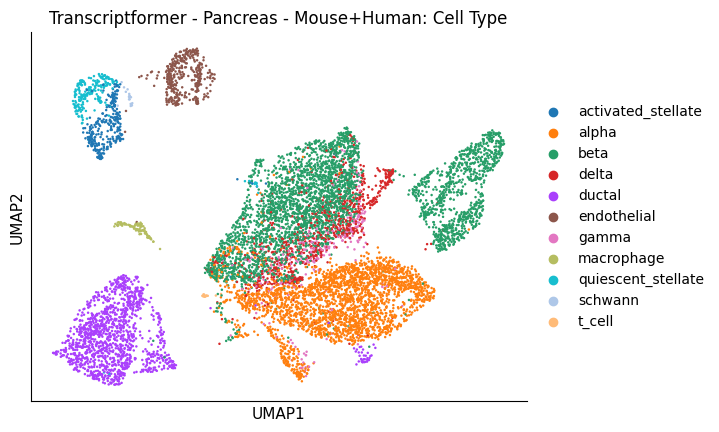

In [ ]:
ax = sc.pl.umap(
    adata,
    color='cell_type',
    frameon=True,
    title=[
        "Transcriptformer - Pancreas - Mouse+Human: Cell Type"],
    show=False,
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

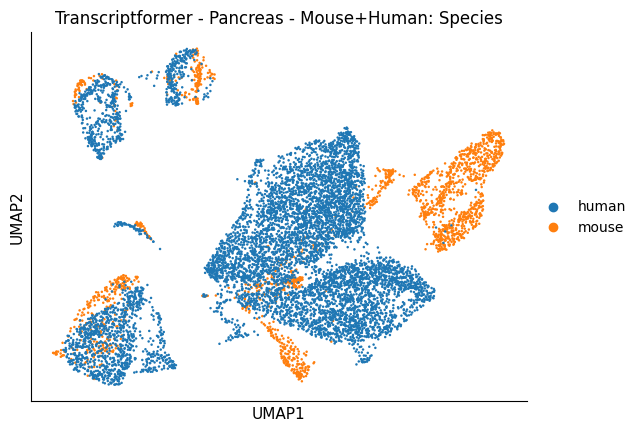

In [ ]:
ax = sc.pl.umap(
    adata,
    color='species',
    frameon=True,
    title=[
        "Transcriptformer - Pancreas - Mouse+Human: Species"],
    show=False,
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

## Evaluate the integration performance

In [ ]:
adata

AnnData object with n_obs × n_vars = 9436 × 0
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch', 'assay'
    uns: 'cell_type_colors', 'species_colors'
    obsm: 'X_transcriptformer', 'X_umap'

In [ ]:
label_keys = ["cell_type", "species"]
scores = compute_silhouette_and_lisi_avg(adata, label_keys,embed_key="X_transcriptformer")

print("Silhouette scores:", scores["silhouette"])
print("LISI scores:", scores["lisi"])

Silhouette scores: {'cell_type': np.float32(0.004703322), 'species': np.float32(0.0893997)}
LISI scores: {'cell_type': 1.2474414478850993, 'species': 1.076061994253683}


## Label Transfer Human=>Mouse

In [ ]:
adata = sc.read_h5ad(os.path.join(embeddings_dir, "transcriptformer_pancreas_cross_species_embeddings.h5ad"))

In [ ]:
adata

AnnData object with n_obs × n_vars = 9436 × 0
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch', 'assay'
    uns: 'neighbors', 'umap'
    obsm: 'X_transcriptformer', 'X_umap'
    obsp: 'connectivities', 'distances'

In [ ]:
adata.obs['species'].value_counts()

,count
species,
human,7568
mouse,1868


In [ ]:
train_data = adata[adata.obs['species'] == 'human'].copy()
test_data  = adata[adata.obs['species'] == 'mouse'].copy()

X_train = train_data.obsm["X_transcriptformer"]
X_test  = test_data.obsm["X_transcriptformer"]

y_train = train_data.obs["cell_type"]
y_test  = test_data.obs["cell_type"]


In [ ]:
adata

AnnData object with n_obs × n_vars = 9436 × 0
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch', 'assay'
    uns: 'neighbors', 'umap'
    obsm: 'X_transcriptformer', 'X_umap'
    obsp: 'connectivities', 'distances'

In [ ]:
# logistic regression
clf = LogisticRegression(max_iter=300, multi_class='multinomial', solver='lbfgs')

clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)

# KNN
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

=== Logistic Regression ===
Accuracy: 0.9486081370449678
                    precision    recall  f1-score   support

activated_stellate       0.93      1.00      0.97        14
             alpha       0.83      0.98      0.90       191
              beta       0.94      1.00      0.97       894
             delta       0.98      0.81      0.89       218
            ductal       1.00      1.00      1.00       275
       endothelial       0.99      0.97      0.98       139
             gamma       0.00      0.00      0.00        41
        macrophage       1.00      1.00      1.00        36
quiescent_stellate       1.00      0.98      0.99        47
           schwann       1.00      0.83      0.91         6
            t_cell       1.00      0.86      0.92         7

          accuracy                           0.95      1868
         macro avg       0.88      0.86      0.87      1868
      weighted avg       0.93      0.95      0.94      1868



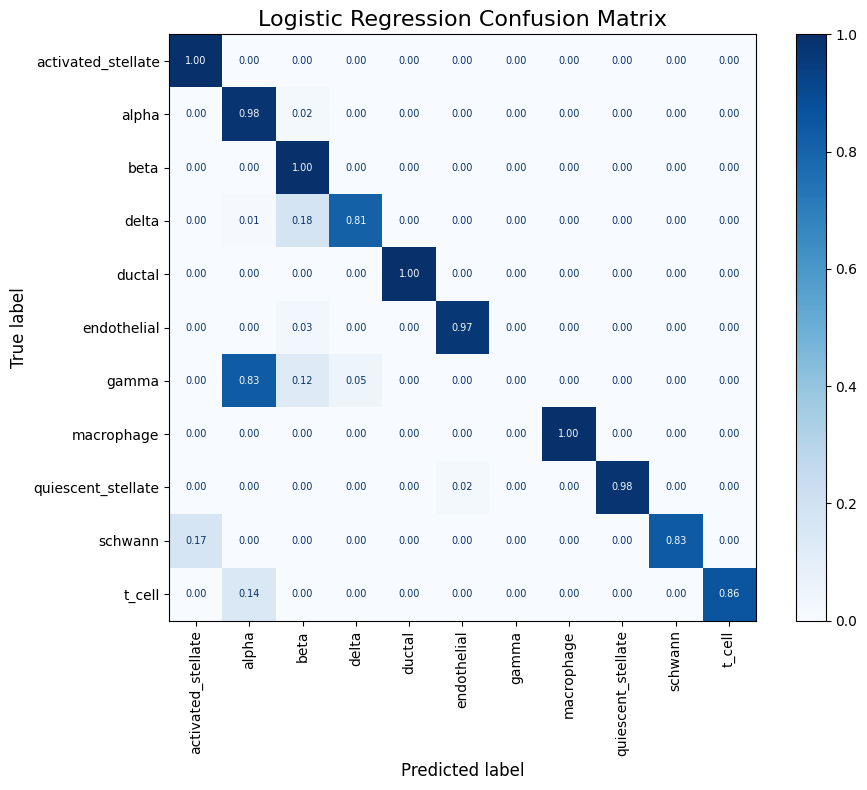


=== k-NN ===
Accuracy: 0.9229122055674518
                    precision    recall  f1-score   support

activated_stellate       0.88      1.00      0.93        14
             alpha       0.82      0.97      0.89       191
              beta       0.91      0.99      0.95       894
             delta       0.90      0.63      0.74       218
            ductal       1.00      1.00      1.00       275
       endothelial       1.00      0.98      0.99       139
             gamma       0.00      0.00      0.00        41
        macrophage       0.97      1.00      0.99        36
quiescent_stellate       1.00      0.98      0.99        47
           schwann       1.00      0.83      0.91         6
            t_cell       1.00      0.86      0.92         7

          accuracy                           0.92      1868
         macro avg       0.86      0.84      0.85      1868
      weighted avg       0.90      0.92      0.91      1868



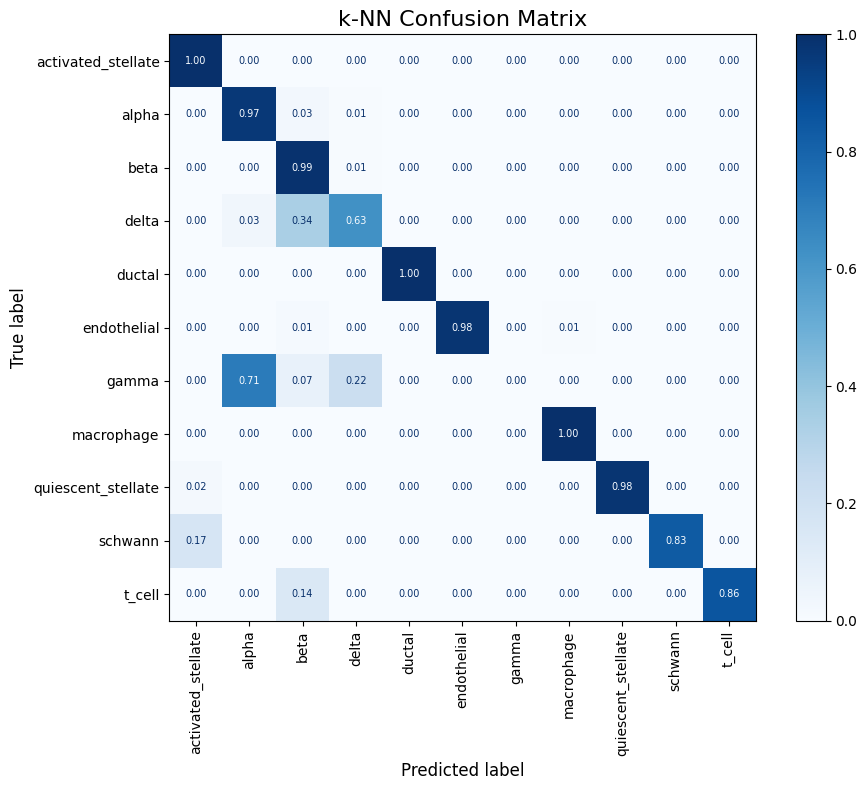

In [ ]:
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
plot_cm(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
plot_cm(y_test, y_pred_knn, "k-NN Confusion Matrix")

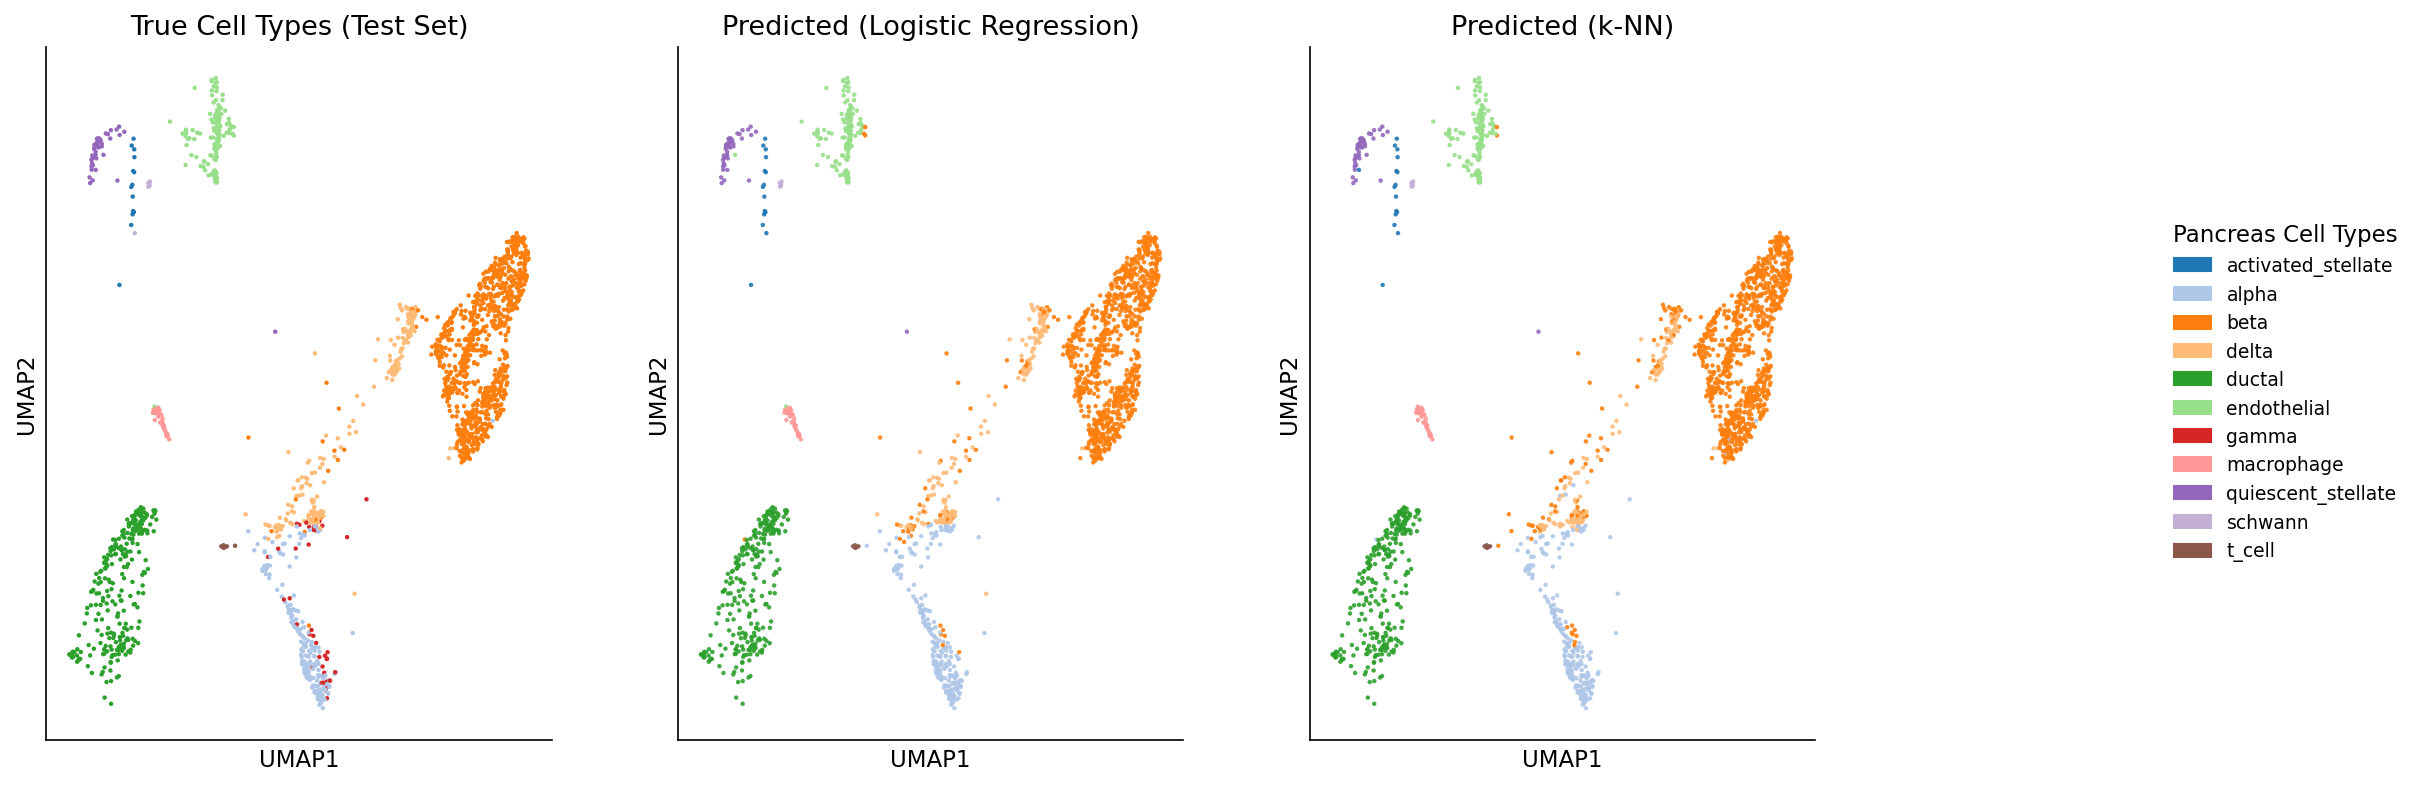

In [ ]:
# Attach predictions to test dataset
test_data.obs["y_pred_lr"] = y_pred_lr
test_data.obs["y_pred_knn"] = y_pred_knn

# Fill missing values
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype(str).fillna("Unassigned")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype(str).fillna("Unassigned")

# Convert to categorical
test_data.obs["cell_type"] = test_data.obs["cell_type"].astype("category")
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype("category")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype("category")

# Unified label set
all_labels = sorted(
    set(test_data.obs["cell_type"].cat.categories)
    | set(test_data.obs["y_pred_lr"].cat.categories)
    | set(test_data.obs["y_pred_knn"].cat.categories)
)

# Force same category order
test_data.obs["cell_type"] = test_data.obs["cell_type"].cat.set_categories(all_labels)
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].cat.set_categories(all_labels)
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].cat.set_categories(all_labels)

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels)}
color_map["Unassigned"] = "lightgray"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=150)

common_kwargs = dict(
    show=False,
    size=18,
    frameon=True,
    palette=color_map
)

# True labels
sc.pl.umap(test_data, color="cell_type", ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Test Set)", fontsize=13)

# Logistic Regression predictions
sc.pl.umap(test_data, color="y_pred_lr", ax=axes[1], alpha=0.9, **common_kwargs)
axes[1].set_title("Predicted (Logistic Regression)", fontsize=13)

# KNN predictions
sc.pl.umap(test_data, color="y_pred_knn", ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (k-NN)", fontsize=13)

# Remove auto legends
for ax in axes:
    # Remove auto legend
    if ax.legend_:
        ax.legend_.remove()

    # Force white background
    ax.set_facecolor("white")

    # Axis labels
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)

    # Make axis lines visible
    ax.spines[['left', 'bottom']].set_visible(True)

    # Remove top/right box lines (clean style)
    ax.spines[['top', 'right']].set_visible(False)

    # Make axes black
    ax.spines[['left', 'bottom']].set_color("black")

    # Ticks
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        colors='black'
    )
# Single clean legend
handles = [Patch(color=color_map[label], label=label) for label in all_labels]
fig.legend(
    handles=handles,
    title="Pancreas Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)
plt.subplots_adjust(right=0.78, wspace=0.25)
plt.show()

## Label Transfer Mouse=>Human

In [ ]:
adata

AnnData object with n_obs × n_vars = 9436 × 0
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch', 'assay'
    uns: 'neighbors', 'umap'
    obsm: 'X_transcriptformer', 'X_umap'
    obsp: 'connectivities', 'distances'

In [ ]:
adata.obs['species'].value_counts()

,count
species,
human,7568
mouse,1868


In [ ]:
train_data = adata[adata.obs['species'] == 'mouse'].copy()
test_data  = adata[adata.obs['species'] == 'human'].copy()

X_train = train_data.obsm["X_transcriptformer"]
X_test  = test_data.obsm["X_transcriptformer"]


y_train = train_data.obs["cell_type"]
y_test  = test_data.obs["cell_type"]


In [ ]:
# logistic regression
clf = LogisticRegression(max_iter=300, multi_class='multinomial', solver='lbfgs')

clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)

# KNN
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

=== Logistic Regression ===
Accuracy: 0.6355708245243129
                    precision    recall  f1-score   support

activated_stellate       0.93      0.95      0.94       284
             alpha       0.97      0.78      0.86      2326
              beta       0.96      0.24      0.38      2525
             delta       0.20      0.96      0.33       601
            ductal       0.98      0.99      0.99      1077
       endothelial       1.00      1.00      1.00       252
             gamma       0.03      0.03      0.03       255
        macrophage       1.00      0.95      0.97        55
quiescent_stellate       0.94      0.87      0.90       173
           schwann       1.00      0.31      0.47        13
            t_cell       0.75      0.86      0.80         7

          accuracy                           0.64      7568
         macro avg       0.80      0.72      0.70      7568
      weighted avg       0.87      0.64      0.66      7568



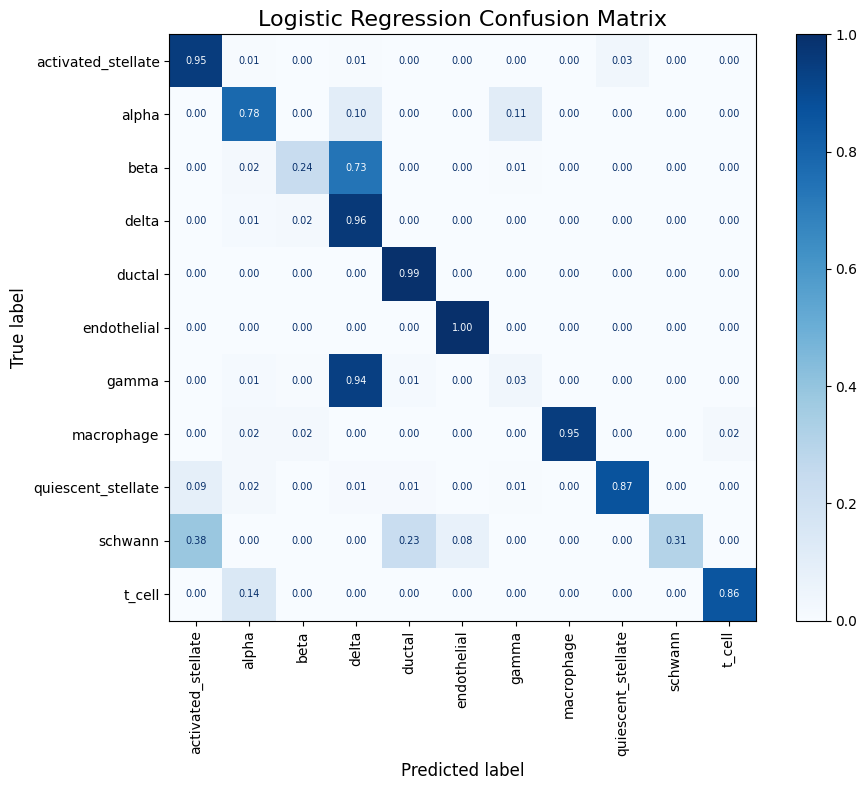


=== k-NN ===
Accuracy: 0.6465380549682875
                    precision    recall  f1-score   support

activated_stellate       0.95      0.93      0.94       284
             alpha       0.96      0.80      0.87      2326
              beta       0.86      0.26      0.40      2525
             delta       0.19      0.94      0.32       601
            ductal       0.99      1.00      0.99      1077
       endothelial       1.00      0.99      0.99       252
             gamma       0.03      0.01      0.01       255
        macrophage       1.00      1.00      1.00        55
quiescent_stellate       0.91      0.90      0.91       173
           schwann       1.00      0.62      0.76        13
            t_cell       0.86      0.86      0.86         7

          accuracy                           0.65      7568
         macro avg       0.80      0.75      0.73      7568
      weighted avg       0.84      0.65      0.67      7568



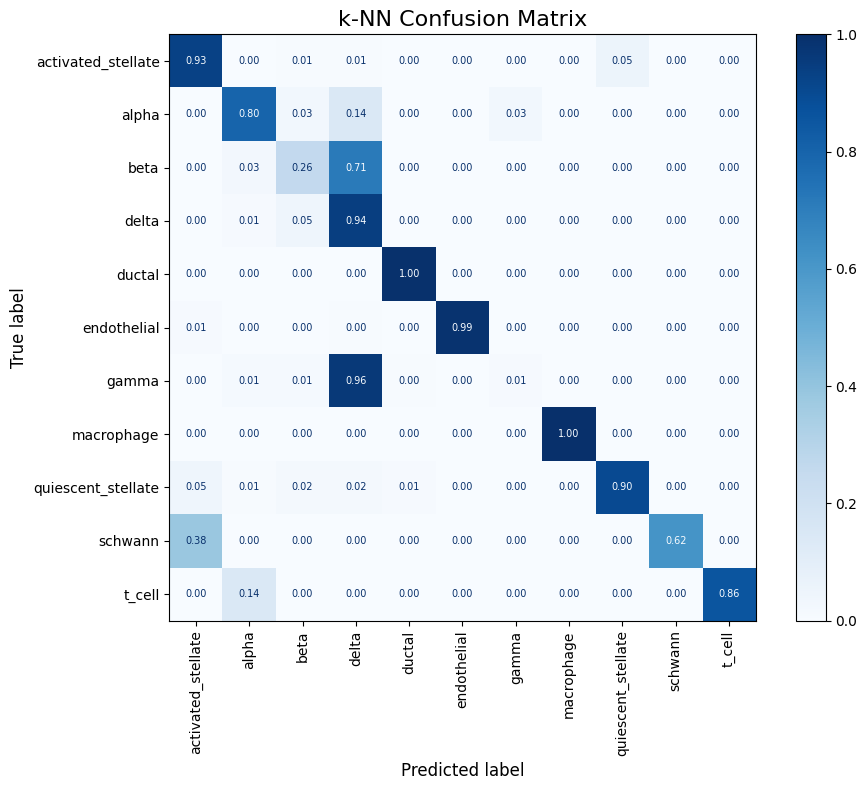

In [ ]:
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
plot_cm(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
plot_cm(y_test, y_pred_knn, "k-NN Confusion Matrix")

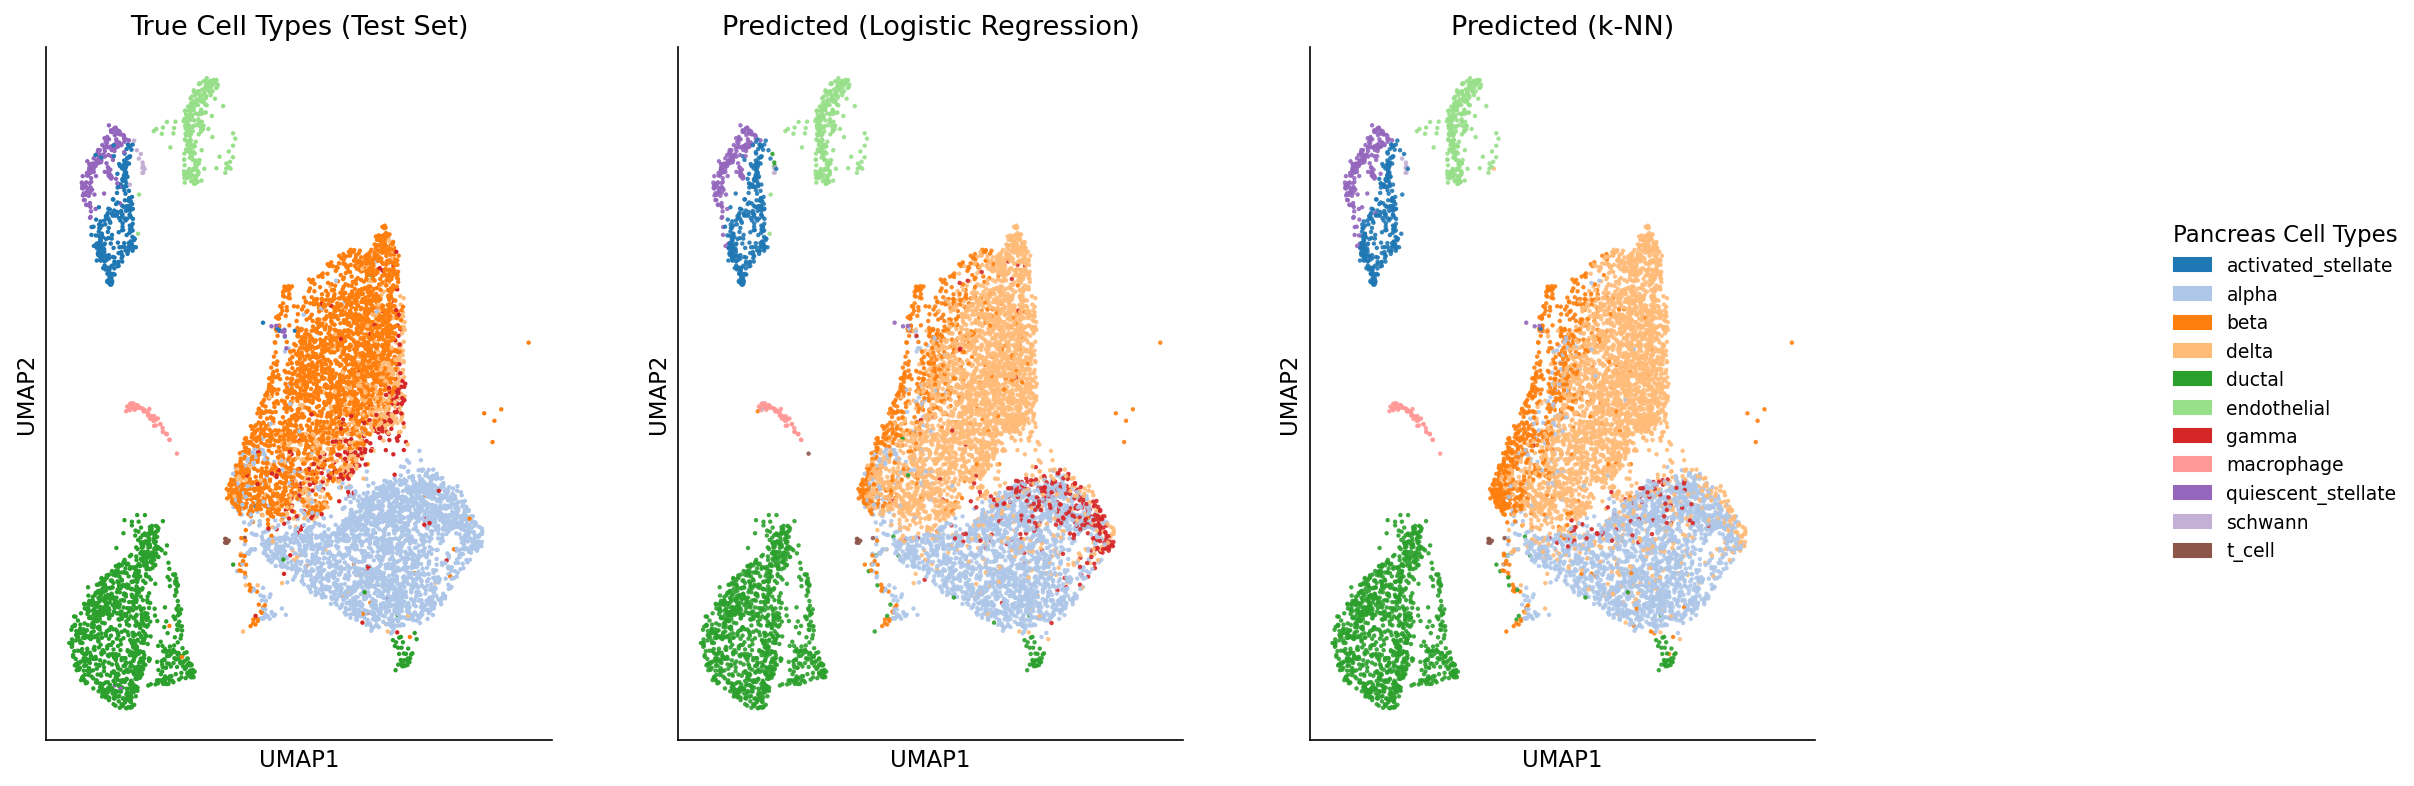

In [ ]:
# Attach predictions to test dataset
test_data.obs["y_pred_lr"] = y_pred_lr
test_data.obs["y_pred_knn"] = y_pred_knn

# Fill missing values
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype(str).fillna("Unassigned")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype(str).fillna("Unassigned")

# Convert to categorical
test_data.obs["cell_type"] = test_data.obs["cell_type"].astype("category")
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype("category")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype("category")

# Unified label set
all_labels = sorted(
    set(test_data.obs["cell_type"].cat.categories)
    | set(test_data.obs["y_pred_lr"].cat.categories)
    | set(test_data.obs["y_pred_knn"].cat.categories)
)

# Force same category order
test_data.obs["cell_type"] = test_data.obs["cell_type"].cat.set_categories(all_labels)
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].cat.set_categories(all_labels)
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].cat.set_categories(all_labels)

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels)}
color_map["Unassigned"] = "lightgray"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=150)

common_kwargs = dict(
    show=False,
    size=18,
    frameon=True,
    palette=color_map
)

# True labels
sc.pl.umap(test_data, color="cell_type", ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Test Set)", fontsize=13)

# Logistic Regression predictions
sc.pl.umap(test_data, color="y_pred_lr", ax=axes[1], alpha=0.9, **common_kwargs)
axes[1].set_title("Predicted (Logistic Regression)", fontsize=13)

# KNN predictions
sc.pl.umap(test_data, color="y_pred_knn", ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (k-NN)", fontsize=13)

# Remove auto legends
for ax in axes:
    # Remove auto legend
    if ax.legend_:
        ax.legend_.remove()

    # Force white background
    ax.set_facecolor("white")

    # Axis labels
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)

    # Make axis lines visible
    ax.spines[['left', 'bottom']].set_visible(True)

    # Remove top/right box lines (clean style)
    ax.spines[['top', 'right']].set_visible(False)

    # Make axes black
    ax.spines[['left', 'bottom']].set_color("black")

    # Ticks
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        colors='black'
    )
# Single clean legend
handles = [Patch(color=color_map[label], label=label) for label in all_labels]
fig.legend(
    handles=handles,
    title="Pancreas Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)
plt.subplots_adjust(right=0.78, wspace=0.25)
plt.show()